In [1]:
import numpy as np

from Utils.load_files import load_binary, get_interval_pairs
from Utils.json_tools import read_formatted_json
from Utils.recording import detect_recording, detect_exposure_time
from Utils.kilosort_utils import gen_adc_spike_time
from pathlib import Path
import matplotlib
# Restart the kernel to revert changes to matplotlib settings
# matplotlib.use('TkAgg')  # Use TkAgg backend for interactive plotting

import matplotlib.pyplot as plt
from Utils.Sessions import Session
from Utils.ttl_utils import intervals_ranges_index_to_frames, fill_short_gaps
from scipy.io import loadmat



32


In [2]:
"""
Change all the variables below to match recording.
"""

is_overwrite_parameters: bool = True
base_dir = r"/mnt/senzailab/Kai/#Recording/m14"

# base_dir = "data"
date: str | int = "260615"

num_of_rec: int = 2

headplate_name: str = 'hp4'

subfolder_filler = f"{date}_{num_of_rec}"

probe_list: list[str] = ["A", "B"]
base_dir = f"{base_dir}/{date}/{subfolder_filler}"


# These are 0 indexed channel numbers
camera_input_channel: int = 1
analogue_input_channel: int = 3

# Index of adc
recording_start_index: int = 0
recording_end_index: int = -1

time_interval: bool = False
is_signal_inverted: bool = True

detect_ADC_DI_threshold, fill_short_gaps_1, fill_short_gaps_2 = 15000, 10, 1000
detect_on_list_threshold: float = 0.5

parameters_file = Path(f'{base_dir}/data/parameters.json')

"""------------------------------------------------------------------"""

oebin_file_dir = next((Path(base_dir) / date).glob("*/experiment1/recording1/structure.oebin"))

session = Session(oebin_file_dir)
session_info = session.get_session_info()

base_data_dir = session_info['base_path']
record_nodes: str = session_info['record_nodes']
recording_name: str = session_info['recording_name']
experiment_id: str = session_info['experiment_id']

path_between = f'/{record_nodes}/{experiment_id}/'
continuous_folder = base_data_dir + path_between + recording_name + '/continuous/'

for probe in probe_list:
    print("==============================")
    print(f"Generating probe{probe} ADC spike time...")
    if (_ := gen_adc_spike_time(session_info=session_info, probe=probe, base_dir=base_dir, num_of_rec=num_of_rec))[0]:
        print(f"probe{probe}_continuous_timestamp saved to {_[1]}")


print("==============================")
print("Loading ADC npy data...")
ADC_name: str = session_info['continuous_ADC_folder']
analogue_total_input_channel_number: int = session_info['ADC_input_channel']
ADC_sampling_rate: float = session_info['ADC_sample_rate']
ADC_datafile = continuous_folder + ADC_name + '/continuous.dat'

photodiode_data = load_binary(ADC_datafile, analogue_total_input_channel_number, analogue_input_channel)[recording_start_index:recording_end_index]


ADC_continuous_time_stamp_file = f'{continuous_folder}/{ADC_name}/timestamps.npy'
ADC_continuous_time_stamp_data = ((ADC_continuous_time_stamp_data_raw := np.load(
    ADC_continuous_time_stamp_file, mmap_mode='r')) - ADC_continuous_time_stamp_data_raw[0])[recording_start_index:recording_end_index]

assert len(ADC_continuous_time_stamp_data) == len(photodiode_data), f"Length mismatch: {len(ADC_continuous_time_stamp_data)} vs {len(photodiode_data)}"

print(f"ADC_continuous_time_stamp_data: {ADC_continuous_time_stamp_data.shape}")
ADC_duration = len(photodiode_data) / ADC_sampling_rate
print(f"ADC duration: {ADC_duration} ")

ADC_DI_data_noGap = fill_short_gaps(~(fill_short_gaps(photodiode_data < 15000, min_gap=10)), min_gap=1000)


assert len(ADC_continuous_time_stamp_data) == len(
    ADC_DI_data_noGap), f"Length mismatch: {len(ADC_continuous_time_stamp_data)} vs {len(ADC_DI_data_noGap)}"

on_list_detected = detect_exposure_time(
    ADC_continuous_time_stamp_data,
    ADC_DI_data_noGap,
    threshold=detect_on_list_threshold,
    time_interval=False,
    is_inverted=is_signal_inverted,
    detection_target_label="on_list",
).ravel()

on_list_detected[-1] = (on_list_detected[-1] -1) if on_list_detected[-1] == len(ADC_continuous_time_stamp_data) else on_list_detected[-1]

on_list_time = ADC_continuous_time_stamp_data[on_list_detected]

#--------------
# manual  correction

# on_list_time = on_list_time[:-2]
on_list_time = on_list_time[2:-4]

trials = loadmat(f"{base_dir}/{date}.mat")["trials"]

assert len(on_list_time) == len(trials), f"Length mismatch: {len(on_list_time)} vs {len(trials)}"

on_list_time = np.append(on_list_time, on_list_time[-1] + 0.1)

if num_of_rec == 2:
    on_list_time = on_list_time[2:]


np.save((npyfile_path := f"{base_dir}/data/on_list_times.npy"), on_list_time)
print(f"on_list_time saved to {npyfile_path}")

NameError: name 'Path' is not defined

In [23]:
camera_data = load_binary(ADC_datafile, analogue_total_input_channel_number, camera_input_channel)

camera_duration = len(camera_data) / ADC_sampling_rate
print(f"camera duration: {camera_duration} ")

exposure_detected = detect_exposure_time(
    ADC_continuous_time_stamp_data,
    camera_data,
    threshold=15000,
    time_interval=False,
    is_inverted=False,
    detection_target_label="exposure",
)


exposure_mid = [
    int((start + end) / 2)
    for start, end in exposure_detected
][1:]

hd_content = read_formatted_json(f"{base_dir}/data/processed/head_direction.json")

hd_raw = hd_content[headplate_name].get('head_direction_deg')
hd = np.asarray(hd_raw, dtype=float)
# hd = hd - 24.610919452941175
hd = (hd % 360)

assert len(exposure_mid) == len(hd), f"Length mismatch: {len(exposure_mid)} vs {len(hd)}"

selected_hd_index = np.searchsorted(exposure_mid, on_list_detected)
selected_hd = hd[selected_hd_index]

selected_hd_pix = selected_hd / 360 * 960

assert len(selected_hd_pix) == len(trials), f"Length mismatch: {len(selected_hd_pix)} vs {len(trials)}"

np.save((npyfile_path := f"{base_dir}/data/hd_trials_times.npy"), selected_hd_pix)
print(f"on_list_time saved to {npyfile_path}")

camera duration: 1301.0173429481363 


Processing exposure files: 100%|██████████| 5/5 [100%]

exposure recording start frame (index): 0


on_list_time saved to /mnt/senzailab/Kai/#Recording/m15/260630/260630_4/data/hd_trials_times.npy


In [40]:
on_list_time[:10]

array([0.00000000e+00, 9.89968321e-05, 1.41168112e+01, 1.42167017e+01,
       1.43168561e+01, 1.44167136e+01, 1.45168680e+01, 1.46167584e+01,
       1.47168799e+01, 1.48167703e+01])

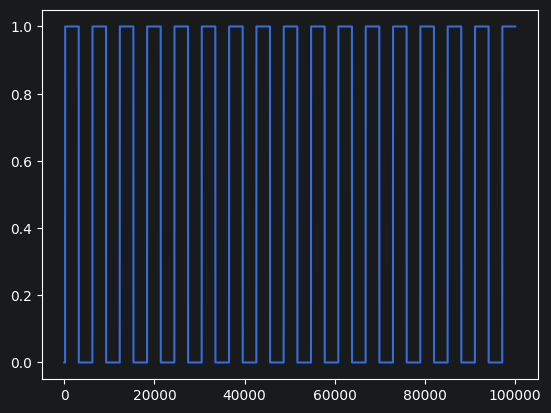

In [119]:
plt.plot(ADC_DI_data_noGap[20000000:20100000])

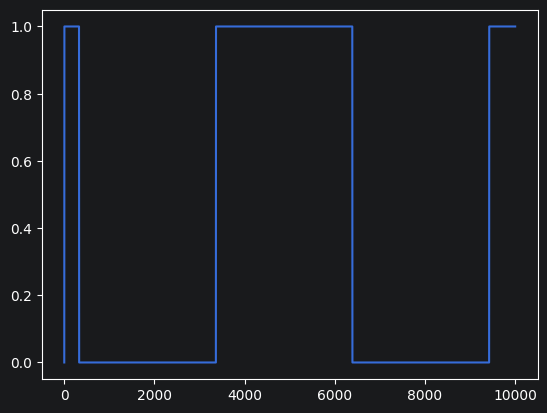

In [37]:
plt.plot(fill_short_gaps((photodiode_data > detect_ADC_DI_threshold)[30000000:30010000], min_gap=1000))

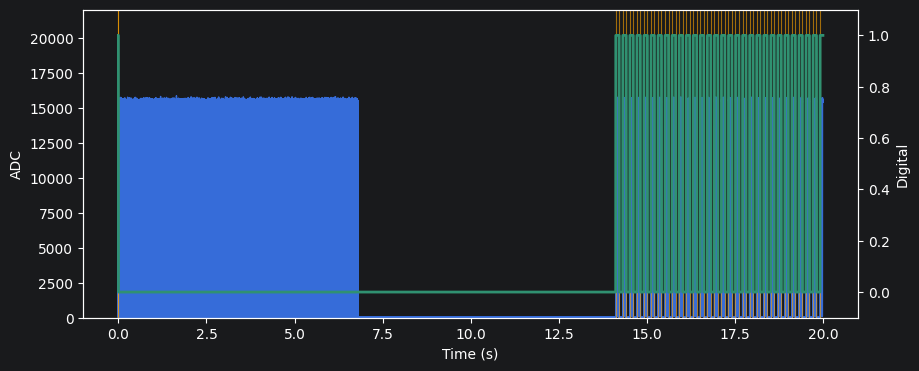

array([     0,      3, 427781, 430808, 433843, 436869, 439904, 442931,
       445965, 448992, 452027, 455053, 458088, 461115, 464149, 467176,
       470211, 473238, 476272, 479299, 482333, 485360, 488395, 491422,
       494456, 497483, 500518, 503544, 506579, 509606, 512640, 515667,
       518702, 521728, 524763, 527790, 530824, 533851, 536886, 539912,
       542947, 545974, 549008, 552035, 555070, 558096, 561131, 564158,
       567192, 570219, 573254, 576280, 579315, 582342, 585376, 588403,
       591438, 594464, 597499, 600526, 603560])

In [43]:
start_time, end_time = 0, 20

start_idx = np.searchsorted(ADC_continuous_time_stamp_data, start_time, side="left")
end_idx = np.searchsorted(ADC_continuous_time_stamp_data, end_time, side="right")

x = ADC_continuous_time_stamp_data[start_idx:end_idx]
y1 = photodiode_data[start_idx:end_idx]
y2 = ADC_DI_data_noGap[start_idx:end_idx]
edges_list = on_list_time

fig, ax1 = plt.subplots(figsize=(10, 4))

l1 = ax1.plot(x, y1, color='C0', lw=1, label='ADC')
ax1.set_ylim(0, 22000)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("ADC")

ax2 = ax1.twinx()
l2 = ax2.plot(x, y2, color='C3', lw=2, label='Digital')
ax2.set_ylim(-0.1, 1.1)
ax2.set_ylabel("Digital")

# Add on_list rising/falling edge markers inside this displayed time window.
# on_list_time is already in the same time base as x.
left = np.searchsorted(edges_list, x[0], side="left")
right = np.searchsorted(edges_list, x[-1], side="right")
visible_edges = edges_list[left:right]

visible_edge_indices = np.searchsorted(ADC_continuous_time_stamp_data, visible_edges)

for t in visible_edges:
    ax1.axvline(t, color="orange", lw=0.8, alpha=0.6)

plt.show()

visible_edge_indices

In [ ]:
np.save((npyfile_path := f"{base_dir}/data/on_list_times.npy"), on_list_idx_patched)


In [ ]:
len(on_list_idx_patched)

In [ ]:
a = on_list_time[10191]  # 47724427
b = on_list_time[10192]  # 47788633
n_insert = 20

normal_dt = np.median(np.diff(on_list_time))
n_interval = round((b - a) / normal_dt)
n_insert = n_interval - 1

inserted_t = np.linspace(a, b, n_insert + 2)[1:-1]

on_list_idx_patched = np.insert(on_list_time, 10192, inserted_t)

In [19]:
on_list_time[790:800]

array([94.19730766, 94.29300796, 95.64291017, 95.73877547, 95.8454318 ,
       95.9416931 , 96.04283841, 96.13870371, 96.24536004, 96.34162134])